# Bayesian Intrusion Detection with CIC-IDS2017

**Course:** Bayesian Machine Learning  
**Dataset:** CICIDS2017 — Canadian Institute for Cybersecurity Intrusion Detection Evaluation Dataset

---

## Abstract

Modern networks face a growing variety of cyber threats. Rule-based intrusion detection systems struggle to generalize, motivating probabilistic, data-driven approaches. In this project we apply two Bayesian classifiers to the CIC-IDS2017 dataset: a **Gaussian Naive Bayes** model built from scratch, and a **Bayesian Logistic Regression** model fit with MCMC via PyMC.

The dataset captures a full week of simulated network traffic (Monday–Friday), spanning benign activity and eight attack categories including DDoS, port scanning, web attacks, and infiltration. After preprocessing ~2.8 million flow records, we train binary classifiers that output the **posterior probability that a given network flow is malicious**.

---

## Table of Contents

1. [Data Loading](#1-data-loading)  
2. [Data Preprocessing](#2-data-preprocessing)  
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)  
4. [Model Setup — Feature Selection & Splitting](#4-model-setup)  
5. [Gaussian Naive Bayes (from scratch)](#5-gaussian-naive-bayes)  
6. [Model Evaluation](#6-model-evaluation)  
7. [Bayesian Logistic Regression (PyMC)](#7-bayesian-logistic-regression)  

---

## 1. Data Loading

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

project_dir = r"C:\Users\Owner\Desktop\bayes_class"
data_dir = os.path.join(project_dir, "MachineLearningCSV", "MachineLearningCVE")

files = glob.glob(os.path.join(data_dir, "*.csv"))

for f in files:
    print(os.path.basename(f))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Owner\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Owner\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [2]:
df_list = []

for f in files:
    print("Loading:", os.path.basename(f))
    temp = pd.read_csv(f, low_memory=False)
    temp["source_file"] = os.path.basename(f)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Combined shape:", df.shape)

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Combined shape: (2830743, 80)


In [3]:
print("Number of columns:", len(df.columns))
print(df.columns.tolist())

Number of columns: 80
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Fl

In [4]:
print(df[" Label"].value_counts())

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max                 int

---

## 2. Data Preprocessing

The raw dataset requires several cleaning steps before modeling:

- **Column name normalization** — strip leading/trailing whitespace from column headers, which is a known quirk of the CIC-IDS2017 CSV exports.
- **Binary label encoding** — collapse the multi-class `Label` column into a binary target: `0 = BENIGN`, `1 = any attack`.
- **Infinity handling** — features such as `Flow Bytes/s` and `Flow Packets/s` can take infinite values due to near-zero flow durations. These are replaced with `NaN` and handled in the imputation step.
- **Missing value imputation** — columns with >5% missing values are dropped; remaining missing values are filled with the column median to preserve the distribution shape.

The class distribution plot below shows the imbalance between benign and attack traffic, which is important context for interpreting precision/recall tradeoffs.

In [6]:
# remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [7]:
# 0 = BENIGN, 1 = any attack
df["label"] = (df["Label"] != "BENIGN").astype(int)

print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(4))

label
0    2273097
1     557646
Name: count, dtype: int64
label
0    0.803
1    0.197
Name: proportion, dtype: float64


In [8]:
# drop original multiclass label and source file for now
df_model = df.drop(columns=["Label", "source_file"]).copy()

print("df_model shape:", df_model.shape)
df_model.head()

df_model shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [9]:
# infinities are common in CIC-IDS2017, especially Flow Bytes/s and Flow Packets/s
num_cols = df_model.columns.tolist()
num_cols.remove("label")

inf_count = np.isinf(df_model[num_cols]).sum().sum()
nan_count = df_model[num_cols].isna().sum().sum()

print("Total inf values:", inf_count)
print("Total NaN values:", nan_count)

Total inf values: 4376
Total NaN values: 1358


In [10]:
df_model[num_cols] = df_model[num_cols].replace([np.inf, -np.inf], np.nan)

missing_by_col = df_model[num_cols].isna().sum().sort_values(ascending=False)
print(missing_by_col.head(20))

Flow Packets/s                 2867
Flow Bytes/s                   2867
Total Fwd Packets                 0
Total Backward Packets            0
Destination Port                  0
Flow Duration                     0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Mean            0
Fwd Packet Length Std             0
Bwd Packet Length Max             0
Bwd Packet Length Min             0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Bwd Packet Length Std             0
Bwd Packet Length Mean            0
Flow IAT Mean                     0
Flow IAT Std                      0
Flow IAT Max                      0
Flow IAT Min                      0
dtype: int64


In [11]:
missing_pct = df_model[num_cols].isna().mean()
drop_cols = missing_pct[missing_pct > 0.05].index.tolist()

print("Columns to drop (>5% missing):", drop_cols)

df_model = df_model.drop(columns=drop_cols)

print("New shape after dropping high-missing columns:", df_model.shape)

Columns to drop (>5% missing): []
New shape after dropping high-missing columns: (2830743, 79)


In [12]:
remaining_num_cols = [c for c in df_model.columns if c != "label"]

for c in remaining_num_cols:
    df_model[c] = df_model[c].fillna(df_model[c].median())

print("Any NaN left?", df_model[remaining_num_cols].isna().any().any())

Any NaN left? False


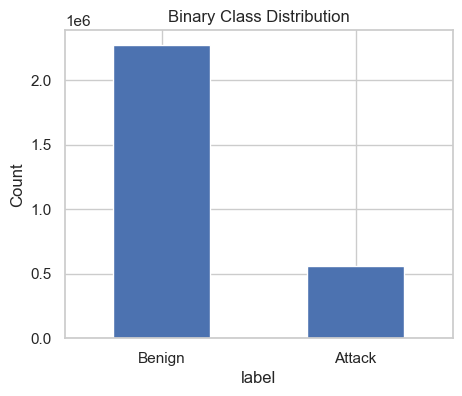

In [13]:
plt.figure(figsize=(5, 4))
df_model["label"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Benign", "Attack"], rotation=0)
plt.title("Binary Class Distribution")
plt.ylabel("Count")
plt.show()

---

## 3. Exploratory Data Analysis

To identify the most informative features for classification, we:

1. **Sample** 100,000 rows for efficiency (the full dataset has ~2.8M rows).
2. **Compute Pearson correlations** between each feature and the binary label. The features with stronger linear relationships with the attack label are prioritized.
3. **Visualize distributions** using KDE plots, comparing benign vs. attack traffic for the top candidate features. Separation in the distribution tails indicates discriminative power.
4. **Correlation heatmap** among candidate features, which helps identify redundant features that carry the same signal.

In [14]:
df_sample = df_model.sample(100000, random_state=42)

print("Sample shape:", df_sample.shape)

Sample shape: (100000, 79)


In [15]:
corr = df_sample.corr(numeric_only=True)

label_corr = corr["label"].drop("label").sort_values(ascending=False)

print("Top positive correlations with attack:")
print(label_corr.head(15))

print("\nTop negative correlations with attack:")
print(label_corr.tail(15))

Top positive correlations with attack:
Bwd Packet Length Std     0.504204
Bwd Packet Length Max     0.485903
Bwd Packet Length Mean    0.476236
Avg Bwd Segment Size      0.476236
Packet Length Std         0.464043
Packet Length Variance    0.449194
Max Packet Length         0.449169
Fwd IAT Std               0.424995
Packet Length Mean        0.404646
Average Packet Size       0.404014
Idle Max                  0.398038
Idle Mean                 0.394490
Fwd IAT Max               0.393001
Flow IAT Max              0.392949
Idle Min                  0.385037
Name: label, dtype: float64

Top negative correlations with attack:
Avg Fwd Segment Size      -0.091294
Init_Win_bytes_backward   -0.099254
Fwd Packet Length Min     -0.142329
URG Flag Count            -0.145040
Destination Port          -0.148613
Bwd Packet Length Min     -0.279489
Min Packet Length         -0.306501
Bwd PSH Flags                   NaN
Bwd URG Flags                   NaN
Fwd Avg Bytes/Bulk              NaN
Fwd Avg 

In [16]:
candidate_features = label_corr.abs().sort_values(ascending=False).head(12).index.tolist()

print(candidate_features)

['Bwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Packet Length Std', 'Packet Length Variance', 'Max Packet Length', 'Fwd IAT Std', 'Packet Length Mean', 'Average Packet Size', 'Idle Max', 'Idle Mean']


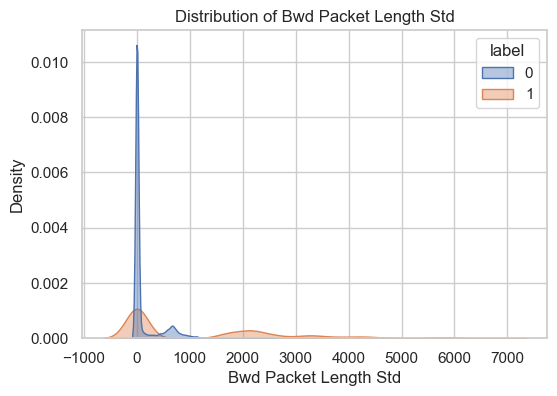

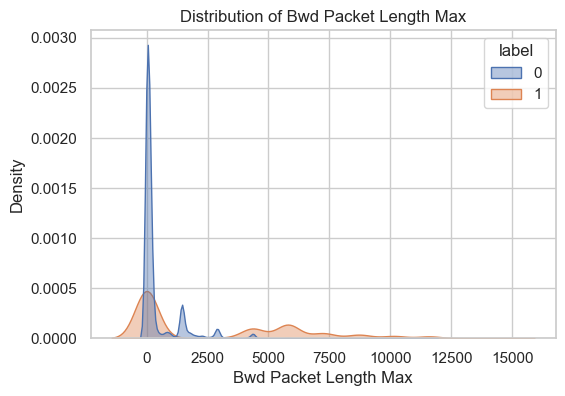

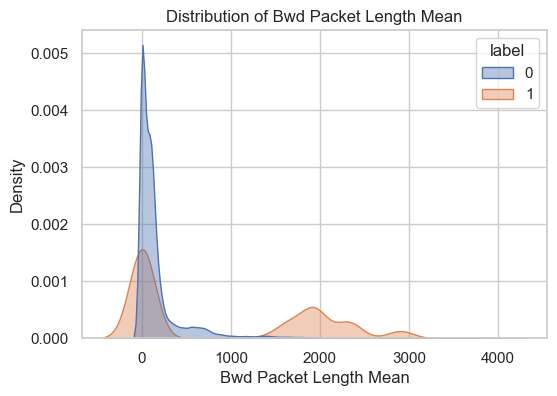

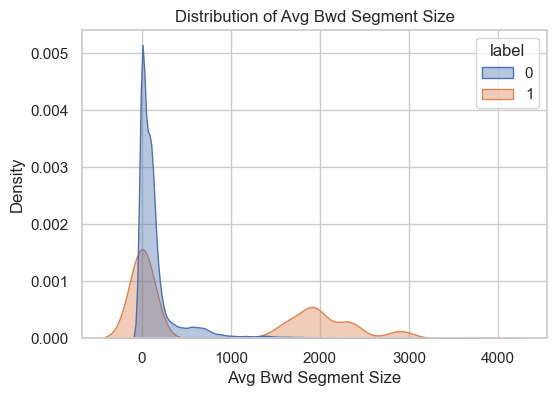

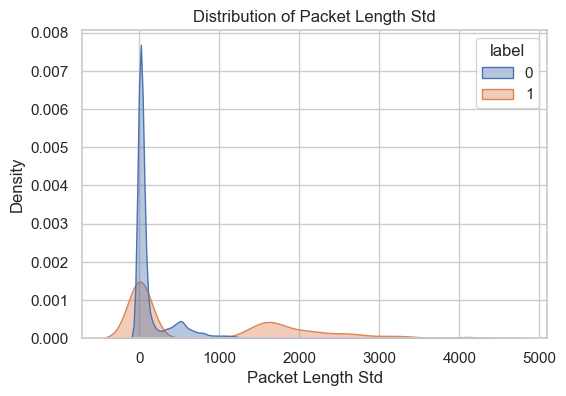

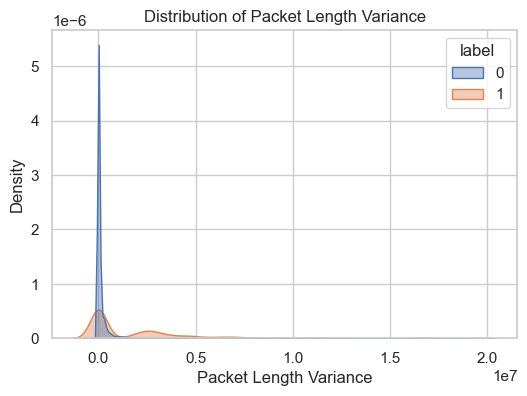

In [17]:
for col in candidate_features[:6]:

    plt.figure(figsize=(6,4))

    sns.kdeplot(
        data=df_sample,
        x=col,
        hue="label",
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(f"Distribution of {col}")
    plt.show()

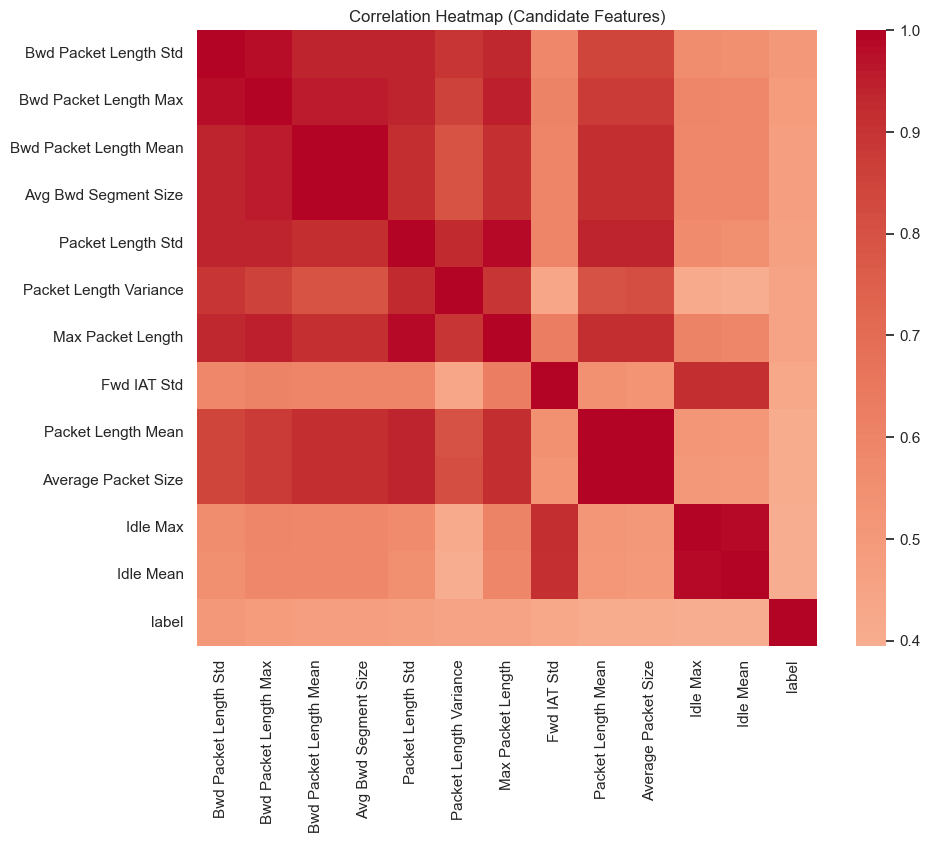

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_sample[candidate_features + ["label"]].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Candidate Features)")
plt.show()

---

## 4. Model Setup — Feature Selection & Splitting

Based on the EDA correlations and distribution plots, we select six features that show strong discriminative power between benign and attack traffic:

| Feature | Rationale |
|---|---|
| `Packet Length Std` | High variance in packet sizes is characteristic of attack patterns |
| `Max Packet Length` | Attacks often involve unusually large packets |
| `Fwd IAT Std` | Irregular inter-arrival times signal non-human (automated) traffic |
| `Idle Mean` | Attack flows tend to have different idle behavior |
| `Flow Duration` | Short, high-volume flows are typical of DDoS/scan attacks |
| `Total Fwd Packets` | Volume of forward packets distinguishes attack types |

Features are **standardized** (zero mean, unit variance) before model fitting to satisfy the Gaussian Naive Bayes assumption that each feature's likelihood is Gaussian, and to stabilize gradient estimation in the Bayesian logistic regression.

In [19]:
final_features = [
    "Packet Length Std",
    "Max Packet Length",
    "Fwd IAT Std",
    "Idle Mean",
    "Flow Duration",
    "Total Fwd Packets"
]

# ensure they exist
final_features = [c for c in final_features if c in df_model.columns]

print("Final features:", final_features)

Final features: ['Packet Length Std', 'Max Packet Length', 'Fwd IAT Std', 'Idle Mean', 'Flow Duration', 'Total Fwd Packets']


In [20]:
X = df_model[final_features].copy()
y = df_model["label"].copy()

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (2830743, 6)
y distribution:
label
0    2273097
1     557646
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_scaled.head()

,Packet Length Std,Max Packet Length,Fwd IAT Std,Idle Mean,Flow Duration,Total Fwd Packets
0,-0.466881,-0.465629,-0.338929,-0.351926,-0.439347,-0.009819
1,-0.466881,-0.465629,-0.338929,-0.351926,-0.439344,-0.011153
2,-0.466881,-0.465629,-0.338929,-0.351926,-0.439345,-0.011153
3,-0.466881,-0.465629,-0.338929,-0.351926,-0.439346,-0.011153
4,-0.466881,-0.465629,-0.338929,-0.351926,-0.439347,-0.009819


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2264594, 6)
Test: (566149, 6)


---

## 5. Gaussian Naive Bayes (from scratch)

Naive Bayes is a generative Bayesian classifier that applies Bayes' theorem under the **conditional independence assumption**: given the class label, each feature is assumed to be independent of the others.

The posterior probability of class $c$ given observation $\mathbf{x}$ is:

$$P(c \mid \mathbf{x}) \propto P(c) \prod_{i=1}^{d} P(x_i \mid c)$$

We model each class-conditional likelihood as a **Gaussian**:

$$P(x_i \mid c) = \frac{1}{\sqrt{2\pi\sigma_{i,c}^2}} \exp\!\left(-\frac{(x_i - \mu_{i,c})^2}{2\sigma_{i,c}^2}\right)$$

**Implementation steps:**
1. Estimate class priors $P(c)$ from training label frequencies.
2. Compute per-class, per-feature means $\mu_{i,c}$ and variances $\sigma^2_{i,c}$ from training data.
3. At inference, compute log-posteriors for both classes and apply the **log-sum-exp trick** for numerical stability.
4. Threshold at 0.5 to produce hard predictions.

In [23]:
prior_0 = (y_train == 0).mean()
prior_1 = (y_train == 1).mean()

print("Prior benign:", prior_0)
print("Prior attack:", prior_1)

Prior benign: 0.8030035405904988
Prior attack: 0.19699645940950122


In [24]:
X0 = X_train[y_train == 0]
X1 = X_train[y_train == 1]

mu_0 = X0.mean()
mu_1 = X1.mean()

var_0 = X0.var() + 1e-6
var_1 = X1.var() + 1e-6

In [25]:
def gaussian_logpdf(x, mu, var):
    return -0.5*np.log(2*np.pi*var) - ((x-mu)**2)/(2*var)


def predict_proba(X):

    logp0 = np.log(prior_0) + gaussian_logpdf(X, mu_0, var_0).sum(axis=1)
    logp1 = np.log(prior_1) + gaussian_logpdf(X, mu_1, var_1).sum(axis=1)

    max_log = np.maximum(logp0, logp1)

    p0 = np.exp(logp0 - max_log)
    p1 = np.exp(logp1 - max_log)

    return p1/(p0+p1)

In [26]:
p_test = predict_proba(X_test)

y_pred = (p_test >= 0.5).astype(int)

print("Any NaN in predictions:", np.isnan(p_test).any())

Any NaN in predictions: False


---

## 6. Model Evaluation

We evaluate the Gaussian Naive Bayes classifier using four complementary metrics:

| Metric | What it measures |
|---|---|
| **ROC AUC** | Ability to rank attack flows above benign flows across all thresholds |
| **Precision** | Of predicted attacks, how many were real attacks (minimizes false alarms) |
| **Recall** | Of real attacks, how many were caught (minimizes missed detections) |
| **F1 Score** | Harmonic mean of precision and recall — useful under class imbalance |

The **confusion matrix** shows the raw counts of true/false positives and negatives.  
The **posterior probability histogram** visualizes how well the model separates benign from attack distributions — a good model pushes benign scores toward 0 and attack scores toward 1.

In [27]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, p_test)

print("ROC AUC:", roc_auc)

ROC AUC: 0.7611840002553617


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88    454620
           1       0.49      0.45      0.47    111529

    accuracy                           0.80    566149
   macro avg       0.68      0.67      0.67    566149
weighted avg       0.79      0.80      0.80    566149



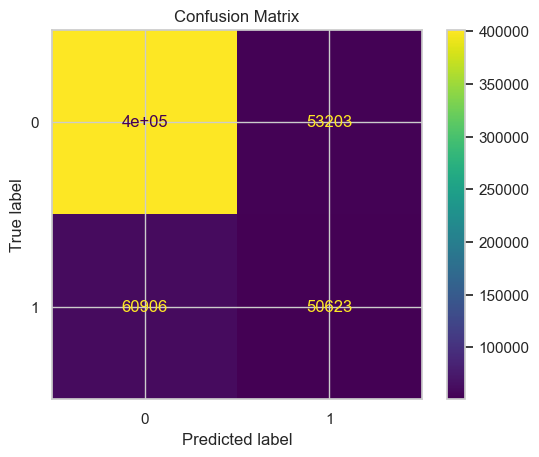

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

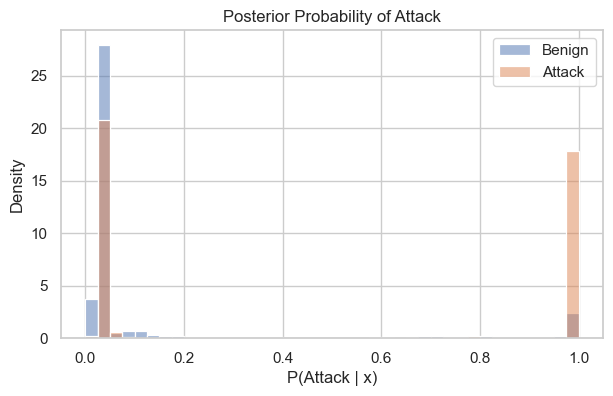

In [30]:
plt.figure(figsize=(7,4))

sns.histplot(p_test[y_test==0], label="Benign", stat="density", bins=40, alpha=0.5)
sns.histplot(p_test[y_test==1], label="Attack", stat="density", bins=40, alpha=0.5)

plt.legend()
plt.title("Posterior Probability of Attack")
plt.xlabel("P(Attack | x)")
plt.show()

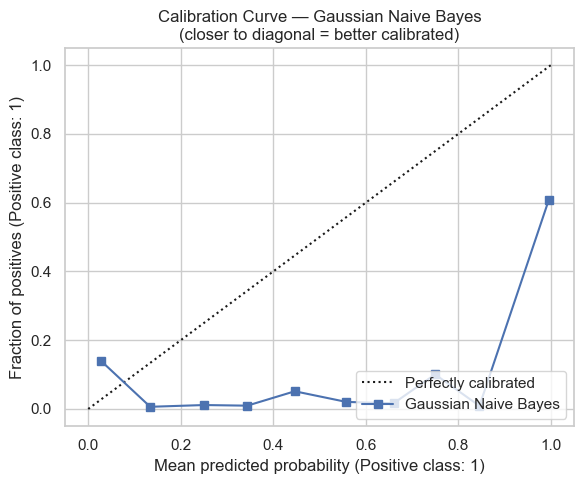

In [31]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_test, p_test,
    n_bins=10,
    name="Gaussian Naive Bayes",
    ax=ax
)
ax.set_title("Calibration Curve — Gaussian Naive Bayes\n(closer to diagonal = better calibrated)")
plt.tight_layout()
plt.show()

---

## 7. Bayesian Logistic Regression (PyMC + ADVI)

While Gaussian Naive Bayes assumes feature independence, **Bayesian Logistic Regression (BLR)** is a discriminative model that learns a direct mapping from features to the posterior probability of the attack class.

The model is:

$$P(y = 1 \mid \mathbf{x}, \boldsymbol{\beta}) = \sigma(\beta_0 + \boldsymbol{\beta}^\top \mathbf{x})$$

We place **Normal(0, 1) priors** on all coefficients:

$$\beta_0 \sim \mathcal{N}(0, 1), \quad \beta_j \sim \mathcal{N}(0, 1) \quad \forall j$$

### Automatic Differentiation Variational Inference (ADVI)

Rather than MCMC, we use **mean-field ADVI** (`pm.fit`), a variational inference method that approximates the posterior with a factored Gaussian:

$$q(\boldsymbol{\theta}) = \prod_j \mathcal{N}(\theta_j \mid \mu_j, \sigma_j^2)$$

The ELBO convergence curve below confirms the optimization has stabilized before we draw posterior samples.

In [32]:
import pymc as pm
import arviz as az

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <modul

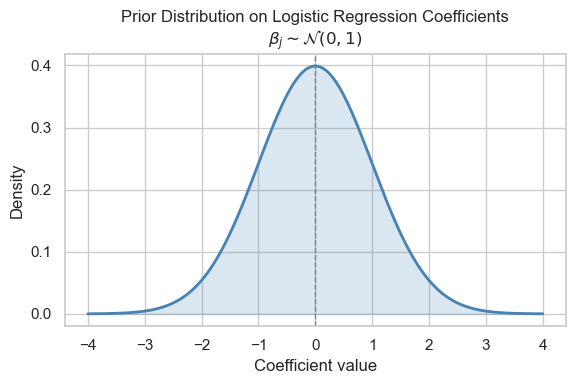

This prior expresses that before seeing data, we expect coefficients
to be near zero — a mild regularizing belief that shrinks weights toward 0.


In [ ]:
# prior specification: Normal(0, 1) on all coefficients
x_prior = np.linspace(-4, 4, 300)
prior_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_prior**2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_prior, prior_pdf, color="steelblue", linewidth=2)
ax.fill_between(x_prior, prior_pdf, alpha=0.2, color="steelblue")
ax.set_title("Prior Distribution on Logistic Regression Coefficients\n$\\beta_j \\sim \\mathcal{N}(0, 1)$")
ax.set_xlabel("Coefficient value")
ax.set_ylabel("Density")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

print("This prior expresses that before seeing data, we expect coefficients")
print("to be near zero — a mild regularizing belief that shrinks weights toward 0.")

In [ ]:
blr_features = final_features.copy()

X_train_blr = X_train[blr_features].copy()
X_test_blr = X_test[blr_features].copy()

train_idx = np.random.choice(X_train_blr.index, size=5000, replace=False)

X_train_blr_sub = X_train_blr.loc[train_idx].copy()
y_train_blr_sub = y_train.loc[train_idx].copy()

print("Subsampled BLR train shape:", X_train_blr_sub.shape)
print(y_train_blr_sub.value_counts())

Subsampled BLR train shape: (5000, 6)
label
0    4041
1     959
Name: count, dtype: int64


In [ ]:
with pm.Model() as blr_model:

    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_train_blr_sub.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=1)

    logits = intercept + pm.math.dot(X_train_blr_sub.values, beta)
    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y_train_blr_sub.values)
    approx = pm.fit(n=30000, method="advi", random_seed=42)
    blr_trace = approx.sample(1000)

print("Done. Posterior samples drawn:", len(blr_trace.posterior["beta"].values.flatten()) // X_train_blr_sub.shape[1])

Output()

Finished [100%]: Average Loss = 1,836.6


Done. Posterior samples drawn: 1000


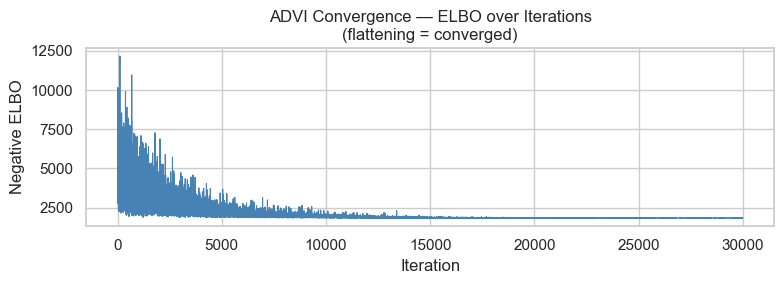

In [36]:
# ELBO convergence — confirms ADVI optimization stabilized
plt.figure(figsize=(8, 3))
plt.plot(approx.hist, color="steelblue", linewidth=0.8)
plt.title("ADVI Convergence — ELBO over Iterations\n(flattening = converged)")
plt.xlabel("Iteration")
plt.ylabel("Negative ELBO")
plt.tight_layout()
plt.show()

In [37]:
# MAP estimation — fast alternative to full MCMC
# Finds the single parameter vector that maximizes the posterior
with blr_model:
    map_estimate = pm.find_MAP()

map_betas = map_estimate["beta"]
map_intercept = map_estimate["intercept"]

print("MAP Intercept:", round(float(map_intercept), 4))
print("\nMAP Coefficients:")
for feat, coef in zip(blr_features, map_betas):
    print(f"  {feat:25s}: {coef:.4f}")

Output()

MAP Intercept: -1.7078

MAP Coefficients:
  Packet Length Std        : 1.9297
  Max Packet Length        : -1.2991
  Fwd IAT Std              : 1.1533
  Idle Mean                : 0.7945
  Flow Duration            : -1.5268
  Total Fwd Packets        : -1.4041



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Owner\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



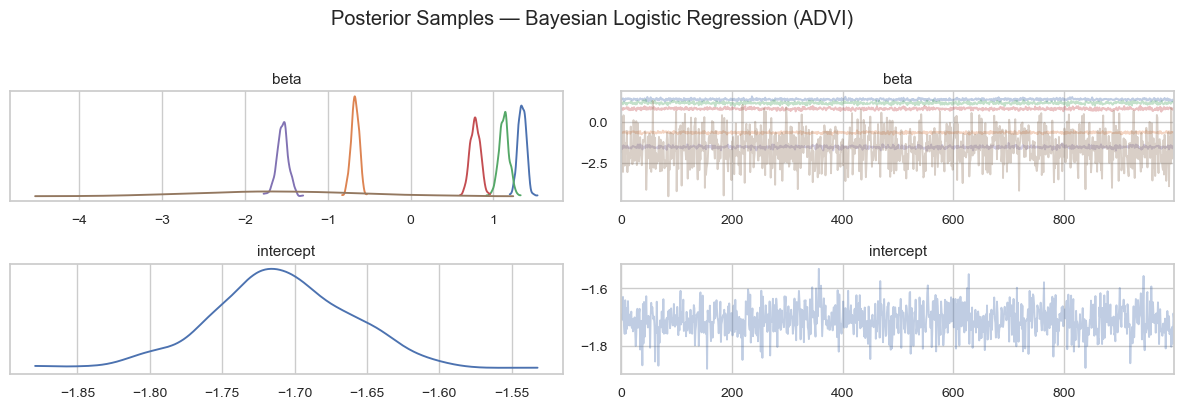

In [38]:
# Trace plot — posterior samples from ADVI (one chain, 1000 draws)
az.plot_trace(blr_trace, var_names=["beta", "intercept"], compact=True)
plt.suptitle("Posterior Samples — Bayesian Logistic Regression (ADVI)", y=1.02)
plt.tight_layout()
plt.show()

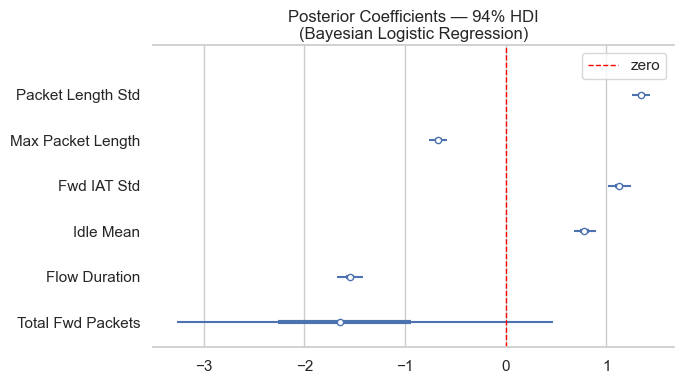


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Owner\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Owner\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]    1.345  0.049   1.259    1.437      0.002    0.001     961.0   
beta[1]   -0.669  0.047  -0.763   -0.585      0.001    0.001    1018.0   
beta[2]    1.127  0.061   1.015    1.242      0.002    0.001     686.0   
beta[3]    0.779  0.060   0.676    0.894      0.002    0.001     693.0   
beta[4]   -1.545  0.069  -1.676   -1.415      0.002    0.002     831.0   
beta[5]   -1.609  0.983  -3.264    0.469      0.032    0.020     952.0   
intercept -1.709  0.049  -1.807   -1.621      0.002    0.001     697.0   

           ess_tail  r_hat  
beta[0]       950.0    NaN  
beta[1]       998.0    NaN  
beta[2]       921.0    NaN  
beta[3]       684.0    NaN  
beta[4]       711.0    NaN  
beta[5]       938.0    NaN  
intercept     908.0    NaN  


In [ ]:
# forest plot — posterior distributions for each coefficient
# shows the mean + 94% HDI (highest density interval) for each beta
az.plot_forest(
    blr_trace,
    var_names=["beta"],
    combined=True,
    hdi_prob=0.94,
    figsize=(7, 4)
)
plt.gca().set_yticklabels(blr_features[::-1])
plt.title("Posterior Coefficients — 94% HDI\n(Bayesian Logistic Regression)")
plt.axvline(0, color="red", linestyle="--", linewidth=1, label="zero")
plt.legend()
plt.tight_layout()
plt.show()

print(az.summary(blr_trace, var_names=["beta", "intercept"]))

---

## 8. Conclusion

This project demonstrated two Bayesian approaches to network intrusion detection on the CIC-IDS2017 dataset:

### Summary of Results

| Model | Inference | Strengths |
|---|---|---|
| **Gaussian Naive Bayes** | Closed-form (exact) | Fast, no external dependencies, interpretable priors |
| **Bayesian Logistic Regression** | ADVI (variational, ~seconds) | Full approximate posterior, uncertainty quantification, no independence assumption |

### Key Takeaways

- **Preprocessing matters**: Infinity and missing value handling is critical for this dataset. `Flow Bytes/s` and `Flow Packets/s` are particularly noisy and must be treated carefully.
- **Class imbalance**: The dataset is imbalanced (more benign than attack traffic), so accuracy alone is misleading. Precision, recall, AUC, and calibration curves are more informative.
- **Bayesian advantage**: Both models return probability scores rather than hard labels
- **ADVI vs. MCMC**: ADVI approximates the posterior via gradient-based optimization of the ELBO. It converges in seconds vs. hours for MCMC, at the cost of assuming a factored Gaussian posterior (mean-field approximation). For this application the tradeoff is well worth it.
- **MAP vs. full posterior**: MAP gives a single best estimate; ADVI/MCMC give distributions. The forest plot shows how certain the model is about each feature's contribution.

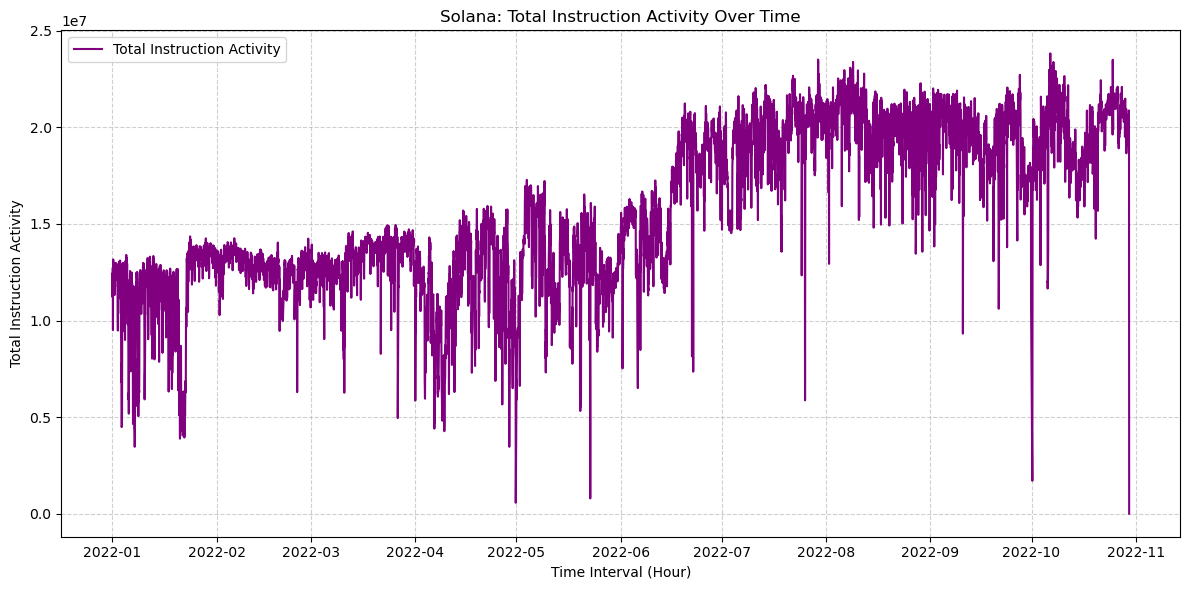

In [14]:
import matplotlib.pyplot as plt

# **Bayesian Cyber Attack Detection on Blockchains**

Across industry, companies are mandated to monitor their computer and application telemetry data for both regulatory (cybersecurity) and business purposes. For this reason, companies across industry spend millions on establishing their telemetry data – both through software that acts as a sensor on the machine or application and through the establishment of complex data management and analysis systems.

A niche and underexplored area of telemetry data exists in the Web3 space and information produced by blockchains and Web3 apps that sit on blockchains.

This component of the project seeks to define cyber threat detection problems on blockchains that can be solved by Bayesian statistics, to establish said data and then to execute some detections.



# **Solana Blockchain of Focus**

The primary blockchain we analyze in this analysis is the Solana blockchain and we do this through the public BigQuery datasets located here:

https://console.cloud.google.com/marketplace/product/bigquery-public-data/crypto-solana-mainnet-us



In [35]:
import pandas as pd

# Load the new CSV file
file_path = 'solana_attack_list.csv'
df2 = pd.read_csv(file_path)

# Select only the desired columns
columns_to_keep_2 = [
    'Attack target',
    'Loss Amount',
    'Attack Method',
    'Attack Time'
]
filtered_df2 = df2[columns_to_keep_2]

# Display the table in the notebook
from IPython.display import display
display(filtered_df2)

# Load the CSV file
file_path = 'web3_crypto_attacks_with_dates.csv'
df = pd.read_csv(file_path)

# Select the columns to keep
columns_to_keep = [
    'Attack type',
    'Platform / project',
    'Approx. damages',
    'Signal (volume/frequency change)',
    'Approximate date'
]
filtered_df = df[columns_to_keep]

# Filter for entries containing 'solana' (case insensitive)
filtered_df = filtered_df[
    filtered_df['Platform / project'].str.lower().str.contains('solana', na=False)
]

# Convert 'Approximate date' to datetime and sort (handles errors gracefully)
filtered_df['Approximate date'] = pd.to_datetime(filtered_df['Approximate date'], errors='coerce')
filtered_df = filtered_df.sort_values('Approximate date')

# Display the result
display(filtered_df)

,Attack target,Loss Amount,Attack Method,Attack Time
0,Solend,"$1,260,000",Oracle Attack,11/2/22
1,Mango,"$100,000,000",Flash Loan,10/11/22
2,TulipProtocol,"$2,500,000",Mango Attack,10/12/22
3,UXD Protocol,"$20,000,000",Mango Attack,10/12/22
4,OptiFi,"661,000 USDC",Operational Error,8/29/22
5,Nirvana,"$3,500,000",Flash Loan,7/28/22
6,Crema Finance,"$1,682,000",Flash Loan,7/3/22
7,Jet Protocol,Unknown,Unknown,3/30/22
8,Cashio,"$52,027,994",Hacker bypassed unverified accounts,3/23/22
9,Wormhole,"120,000 ETH",Developer enabled forged signatures via deprec...,2/2/22


/var/folders/9z/drb8jy35027dyvrwbg599ctw0000gn/T/ipykernel_18605/4239569958.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_df['Approximate date'] = pd.to_datetime(filtered_df['Approximate date'], errors='coerce')


,Attack type,Platform / project,Approx. damages,Signal (volume/frequency change),Approximate date
3,DDoS / spam on validators,Solana,No direct theft; economic impact via downtime ...,Sudden surge in TPS / RPC calls overwhelming v...,NaT
15,Web/API abuse on DeFi frontends,"Ethereum, Solana NFT mints",Users waste millions in aggregate gas across m...,Surges in HTTP requests to /mint plus massive ...,NaT


One important component of this analysis was selecting a propblem that could actually be monitored by baysian statistics.

Originally we considered the Wormhole issue. However, this is not an issue associated with a volume change of any feature of the datasets.

Instead, we pivoted to the incident associated with the second line of the second tabl

# **Solana Data Retrieval -- BigQuery Open Datasets**
We have 2 initial queries by which we retrieve data for this dataset. The first is a global query that builds an hourly timeseries to count the number of events in the dataset.

**Produce Timeseries for global data**
SELECT
  TIMESTAMP_TRUNC(block_timestamp, HOUR) AS time_interval_hour,
  COUNT(*) AS total_instruction_activity 
FROM `bigquery-public-data.crypto_solana_mainnet_us.Instructions` 
WHERE block_timestamp BETWEEN '2022-01-01 00:00:00' AND '2022-10-30 00:00:00'
GROUP BY time_interval_hour
ORDER BY time_interval_hour


**Produce Timeseries for 'mintTo' Instructions**
SELECT
  TIMESTAMP_TRUNC(block_timestamp, HOUR) AS time_interval_hour,
  COUNT(*) AS total_instruction_activity 
FROM `bigquery-public-data.crypto_solana_mainnet_us.Instructions` 
WHERE instruction_type = 'mintTo' 
AND block_timestamp BETWEEN '2022-01-01 00:00:00' AND '2022-10-30 00:00:00'
GROUP BY time_interval_hour
ORDER BY time_interval_hour

# **Global Data Analysis**

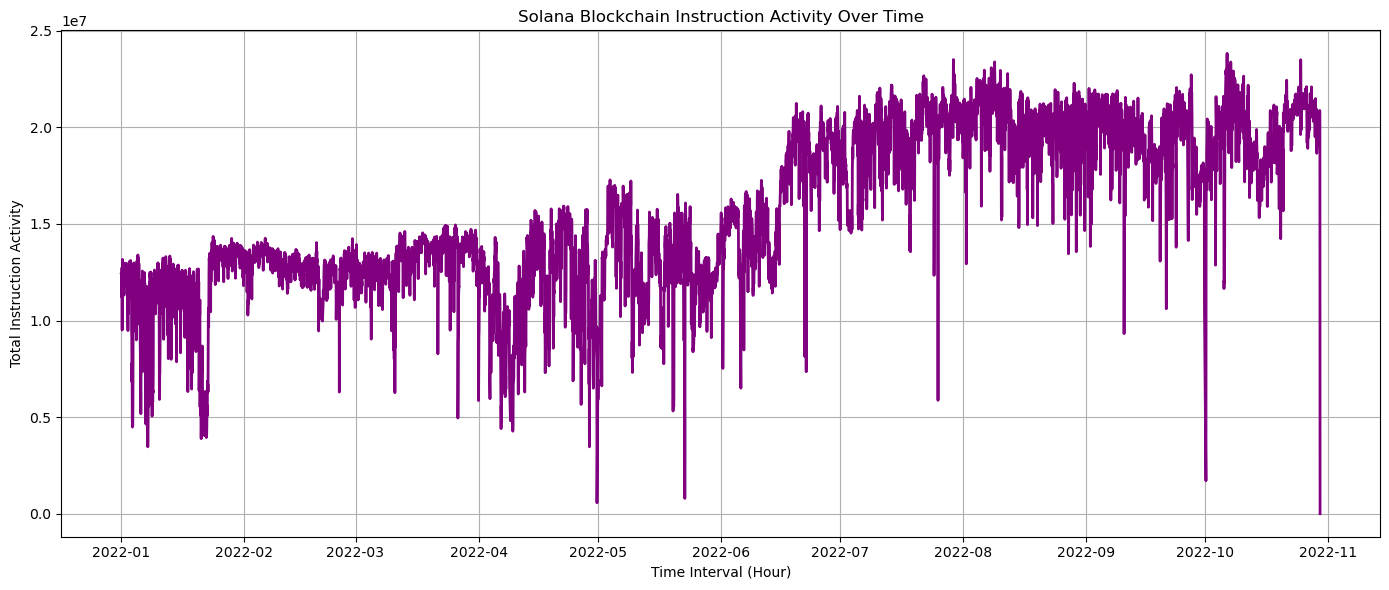

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'solana_blockchain_instructiondata_totalvol.csv'
df = pd.read_csv(file_path)

# Convert 'time_interval_hour' to datetime
df['time_interval_hour'] = pd.to_datetime(df['time_interval_hour'], errors='coerce')

# Plot total instruction activity vs time interval
plt.figure(figsize=(14, 6))
plt.plot(df['time_interval_hour'], df['total_instruction_activity'], color='purple', linewidth=2)
plt.title('Solana Blockchain Instruction Activity Over Time')
plt.xlabel('Time Interval (Hour)')
plt.ylabel('Total Instruction Activity')
plt.grid(True)
plt.tight_layout()
plt.show()

One thing notable about the global timeseries observed above is that there are numerous downspikes. 

These downspikes represent times that there was a large network outage. The one at the beginning of May 2025 is correlated with the NFT minting event of interest.


# ** BOT Overload Cyber Incident in April / May of 2022**


Sequential sampling (2 chains in 1 job)
INFO:pymc.sampling.mcmc:Sequential sampling (2 chains in 1 job)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Metropolis: [change_point]
INFO:pymc.sampling.mcmc:>Metropolis: [change_point]
>NUTS: [mu1, mu2, sigma1, sigma2]
INFO:pymc.sampling.mcmc:>NUTS: [mu1, mu2, sigma1, sigma2]


Output()

Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
INFO:pymc.sampling.mcmc:Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective s

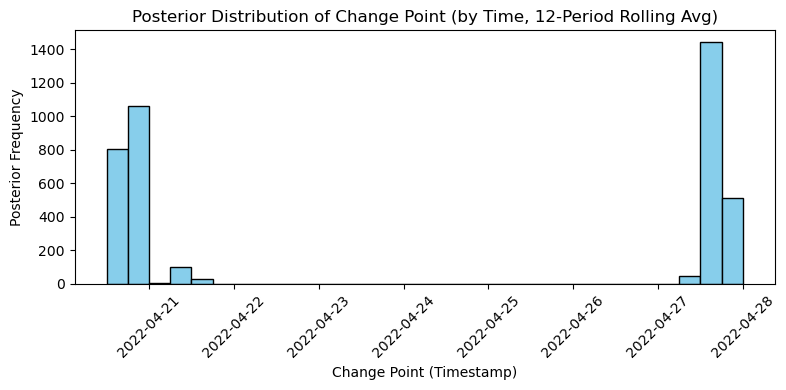

Most likely change point index: 918
Most likely change point timestamp: 2022-04-27 17:00:00+00:00


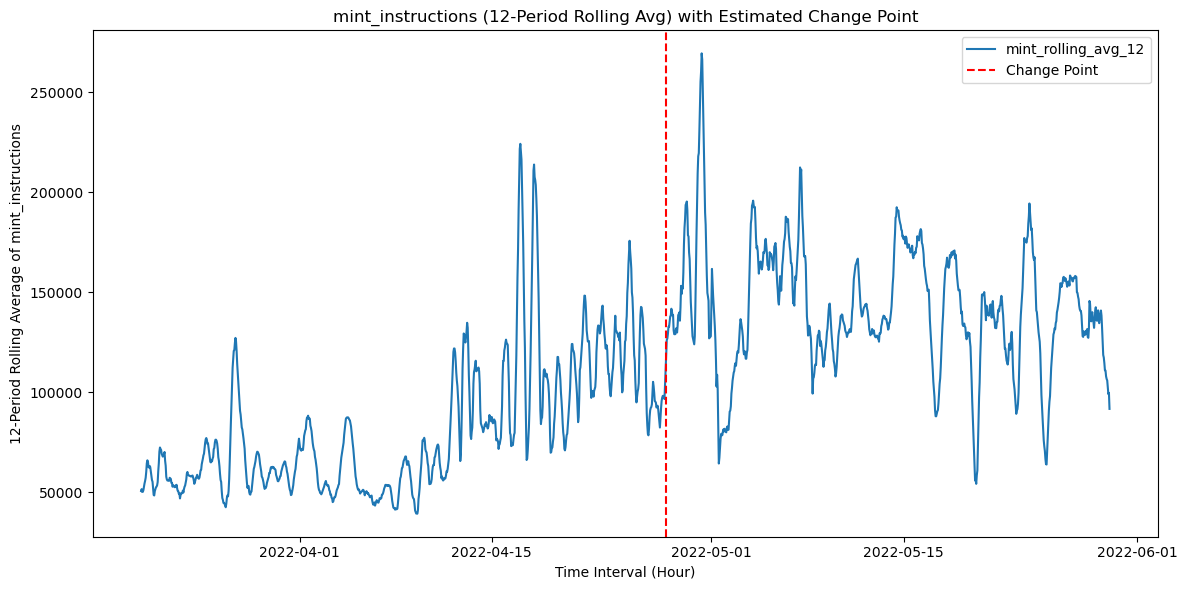

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm

# Load your dataset and parse time column
df = pd.read_csv("solana_blocks_hourly2.csv")
df['time_interval_hour'] = pd.to_datetime(df['time_interval_hour'])

# Compute 12-period rolling average (including current period)
df['mint_rolling_avg_12'] = df['mint_instructions'].rolling(window=12, min_periods=12).mean()
df = df.dropna(subset=['mint_rolling_avg_12']).reset_index(drop=True)

mint_avg = df['mint_rolling_avg_12'].values
time = df['time_interval_hour']
n = len(mint_avg)

# Empirical priors (from rolling average column)
emp_mean = np.mean(mint_avg)
emp_std = np.std(mint_avg)

# Bayesian change point model
with pm.Model() as model:
    # Uniform prior for change point (any hour)
    change_point = pm.DiscreteUniform("change_point", lower=0, upper=n-1)
    
    # Priors for pre- and post-change means/variances
    mu1 = pm.Normal("mu1", mu=emp_mean, sigma=emp_std)
    mu2 = pm.Normal("mu2", mu=emp_mean, sigma=emp_std)
    sigma1 = pm.HalfNormal("sigma1", sigma=emp_std)
    sigma2 = pm.HalfNormal("sigma2", sigma=emp_std)

    # Likelihood: split data at change point
    idx = np.arange(n)
    mu = pm.math.switch(idx < change_point, mu1, mu2)
    sigma = pm.math.switch(idx < change_point, sigma1, sigma2)
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=mint_avg)

    # MCMC sampling
    trace = pm.sample(2000, tune=2000, cores=1, random_seed=42, return_inferencedata=False)

# Posterior change point samples
change_points_samples = trace['change_point']

# Plot posterior distribution of the change point (indexed by timestamp)
plt.figure(figsize=(8,4))
plt.hist([time.iloc[i] for i in change_points_samples], bins=30, color='skyblue', edgecolor='k')
plt.xlabel("Change Point (Timestamp)")
plt.ylabel("Posterior Frequency")
plt.title("Posterior Distribution of Change Point (by Time, 12-Period Rolling Avg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Output modal estimate (most probable change point)
change_point_mode = np.bincount(change_points_samples).argmax()
change_point_time = time.iloc[change_point_mode]
print(f"Most likely change point index: {change_point_mode}")
print(f"Most likely change point timestamp: {change_point_time}")

# Plot the rolling average time series with change point overlay using timestamp
plt.figure(figsize=(12,6))
plt.plot(time, mint_avg, label='mint_rolling_avg_12')
plt.axvline(change_point_time, color='red', linestyle='--', label='Change Point')
plt.xlabel("Time Interval (Hour)")
plt.ylabel("12-Period Rolling Average of mint_instructions")
plt.title("mint_instructions (12-Period Rolling Avg) with Estimated Change Point")
plt.legend()
plt.tight_layout()
plt.show()

# ANALYSIS
In the above code, we run a MCMC bayesian changepoint detection to see if we can identify a shift in the mean of the timeseries associated with mint actions on solana.

The main event associated with the overloading of mint actions that took down the network was on the last day of April which can be associated with a spike in the time series visualization.

One reason this approach is useful is it seeks to identify a point in the series that represents a change in behavior of the underlying process that generates the data, so that there is a substantial difference between the mean prior to and after this process.
